In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns  

Matplotlib is building the font cache; this may take a moment.


In [2]:
# 1. Load dataset
df = pd.read_excel('shipwreckdatabase.xlsx')
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [3]:
# Ensure description is string
df['description'] = df['description'].astype(str)
print(f"Dataset shape: {df.shape}")
print("Classification labels:", df['classification'].unique())

Dataset shape: (28234, 7)
Classification labels: ['Schooner' 'Sloop' 'Iron Steamship' 'Brig' 'Unknown' 'Lugger' 'Snow'
 'Steamship' 'Smack' 'Yawl' 'Steel Steamship' 'Cutter' 'Ketch'
 'Brigantine' 'Lighter' 'Barque' 'Yacht' 'Ship' 'Fishing boat'
 'Crane Vessel' 'Tender' 'Barquentine' 'Collier' 'Dutch Galliot'
 'Screw Steamer' 'Flat' 'Bark' 'Boat' 'Trader' 'Carvel' 'Lugsail'
 'Galliot' 'Dandy' 'Clinker' 'Iron Paddle Steam Tug' 'Sailing Ship'
 'Merchant Vessel' 'Pleasure Boat' 'Trawler' 'Pilot boat' 'Barge'
 'Admiralty/ Decoy Ship' 'Steam Trawler' 'Submarine' 'Sailing Boat'
 'Paddler Steamer' 'Motor Boat' 'Packet boat' 'Wherry' 'Coaster' 'Clipper'
 'Cruiser' 'Vessel' 'Iron Steam Yacht' 'Smack Yacht' 'Hacker' 'Jigger'
 'Tug' 'Wooden Steam Tug' 'Frigate' 'Hobble' 'Steam Tug' 'Stone hacker'
 'Gabbard' 'West Indiaman' 'Skiff' "Man O' War" 'Anti-submarine Drifter'
 'Light Ship' 'Steam Drifter' 'Fishing drifter' 'Lifeboat'
 'Coast Guard Cruiser' 'Iron steam tug' 'Motor Fishing Vessel'
 'Steam P

In [4]:
# Drop rows with missing descriptions
df.dropna(subset=['description'], inplace=True)

In [5]:
print(df[['wreck_name','classification', 'place_of_loss', 'date_of_loss', 'description']].head())

           wreck_name  classification  \
0               Actur        Schooner   
1         Anne McLeod        Schooner   
2  Barbara & Jannette           Sloop   
3            Bee (SS)  Iron Steamship   
4               Bloom        Schooner   

                                       place_of_loss date_of_loss  \
0  Carlingford Bar to Greencastle pier, Carlingfo...   28/12/1894   
1               Carlingford, near, Carlingford Lough   22/01/1862   
2  Carlingford Bar, outside, on a rock, Carlingfo...   18/02/1824   
3      Carlingford Lough entrance/ Helly Hunter Rock   19/10/1888   
4                 Carlingford Bar, Carlingford Lough   23/10/1838   

                                         description  
0  Schooner of Dublin, stranded en route to Cunni...  
1  71-ton, 6-year-old schooner. Captain was Darby...  
2  Sloop en route from Irvine to Dundalk, struck ...  
3  88-ton, 18-year-old iron steamship. Owned by ‘...  
4  Schooner valued at £600, became a total wreck,...  


In [6]:
# 2. Extract cause from description
def extract_cause(desc):
    desc = desc.lower()
    if 'torpedo' in desc:
        return 'torpedoed'
    elif 'mine' in desc:
        return 'mined'
    elif 'ran aground' in desc or 'rock' in desc:
        return 'ran aground'
    elif 'storm' in desc or 'weather' in desc or 'typhoon' in desc or 'cyclone' in desc:
        return 'bad weather'
    elif 'collision' in desc or 'collided' in desc:
        return 'collision'
    elif 'fire' in desc or 'explosion' in desc or 'burn' in desc:
        return 'fire/explosion'
    elif 'sank' in desc or 'sinking' in desc or 'water leakage' in desc or 'flood' in desc:
        return 'sank'
    elif 'naval battle' in desc or 'air raid' in desc or 'gunfire' in desc:
        return 'naval battle'
    elif 'ice' in desc:
        return 'iceberg wreck'
    elif 'scuttle' in desc:
        return 'scuttle'
    elif 'wreck' in desc:
        return 'wrecked'
    elif 'stranded' in desc or 'abandon' in desc or 'foundered' in desc:
        return 'foundered'
    else:
        return 'unknown reasons'



In [7]:
df['cause'] = df['description'].apply(extract_cause)

In [8]:
print("\nLabel distribution (before cleaning):")
print(df['cause'].value_counts())



Label distribution (before cleaning):
cause
unknown reasons    14520
foundered           5191
wrecked             3104
torpedoed            976
sank                 904
ran aground          837
fire/explosion       626
bad weather          592
collision            548
mined                338
naval battle         303
scuttle              244
iceberg wreck         51
Name: count, dtype: int64


In [10]:
#  Remove unknown causes globally
df = df[df['cause'] != 'unknown reasons'].copy()


In [11]:
print("\nLabel distribution (after removing unknown):")
print(df['cause'].value_counts())



Label distribution (after removing unknown):
cause
foundered         5191
wrecked           3104
torpedoed          976
sank               904
ran aground        837
fire/explosion     626
bad weather        592
collision          548
mined              338
naval battle       303
scuttle            244
iceberg wreck       51
Name: count, dtype: int64


In [12]:
# 3. Prepare for supervised learning
X = df['description']
y = df['cause']



In [13]:
# Vectorize text
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_vec = vectorizer.fit_transform(X)



In [14]:
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42, stratify=y
)


In [15]:
# 4. Train a classifier
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
# Predict and evaluate
y_pred = model.predict(X_test)


In [17]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))




Classification Report:
                precision    recall  f1-score   support

   bad weather       0.97      0.89      0.93       118
     collision       0.96      0.95      0.95       110
fire/explosion       0.99      0.87      0.93       125
     foundered       0.99      1.00      0.99      1038
 iceberg wreck       0.00      0.00      0.00        10
         mined       0.75      0.74      0.74        68
  naval battle       1.00      0.98      0.99        61
   ran aground       0.97      0.90      0.94       167
          sank       0.93      0.94      0.94       181
       scuttle       0.92      0.96      0.94        49
     torpedoed       0.99      0.95      0.97       195
       wrecked       0.92      1.00      0.96       621

      accuracy                           0.96      2743
     macro avg       0.87      0.85      0.86      2743
  weighted avg       0.96      0.96      0.96      2743



C:\Users\drapa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\drapa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\drapa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


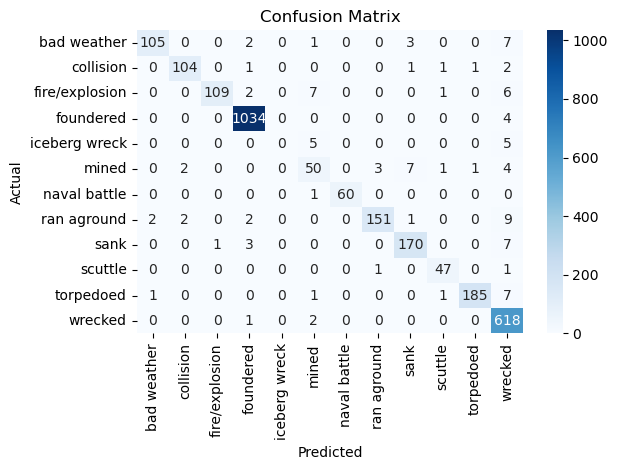

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [19]:
# 5. Analyze wreck locations
print("\nTop locations with the most shipwrecks:")

df = df.dropna(subset=['place_of_loss'])
df['place_of_loss'] = df['place_of_loss'].astype(str).str.strip().str.lower()

location_counts = df['place_of_loss'].value_counts().head(10)
print(location_counts)




Top locations with the most shipwrecks:
place_of_loss
sable island                    152
at sea                          136
unknown                         134
halifax harbour                  62
dublin, river liffey, n bull     61
wexford, near                    59
arklow bank, co wicklow          59
blackwater bank, co wexford      52
seal island                      46
dun laoghaire harbour            46
Name: count, dtype: int64


C:\Users\drapa\AppData\Local\Temp\ipykernel_4212\3741456334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_counts.values, y=location_counts.index, palette='mako')


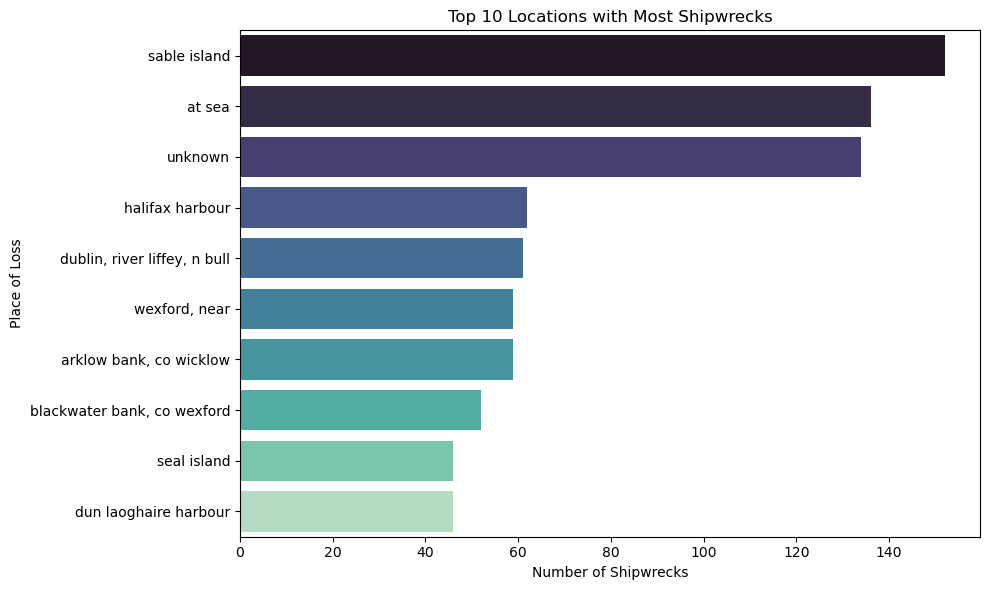

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x=location_counts.values, y=location_counts.index, palette='mako')
plt.title("Top 10 Locations with Most Shipwrecks")
plt.xlabel("Number of Shipwrecks")
plt.ylabel("Place of Loss")
plt.tight_layout()
plt.show()



In [21]:
# 6. Cross-analysis: cause vs. location
cause_location = df.groupby(['place_of_loss', 'cause']).size().reset_index(name='count')

top_combinations = cause_location.sort_values('count', ascending=False).head(10)

print("\nTop 10 (Location, Cause) combinations:")
print(top_combinations)



Top 10 (Location, Cause) combinations:
                    place_of_loss        cause  count
5797                 sable island      wrecked    128
312                        at sea    foundered     99
6878                      unknown      wrecked     64
6875                      unknown    foundered     60
7105                wexford, near    foundered     44
861   blackwater bank, co wexford    foundered     38
3319          greenore to wexford  bad weather     30
174       arklow bank, co wicklow      wrecked     30
5956              scatarie island    foundered     26
6009                  seal island      wrecked     24


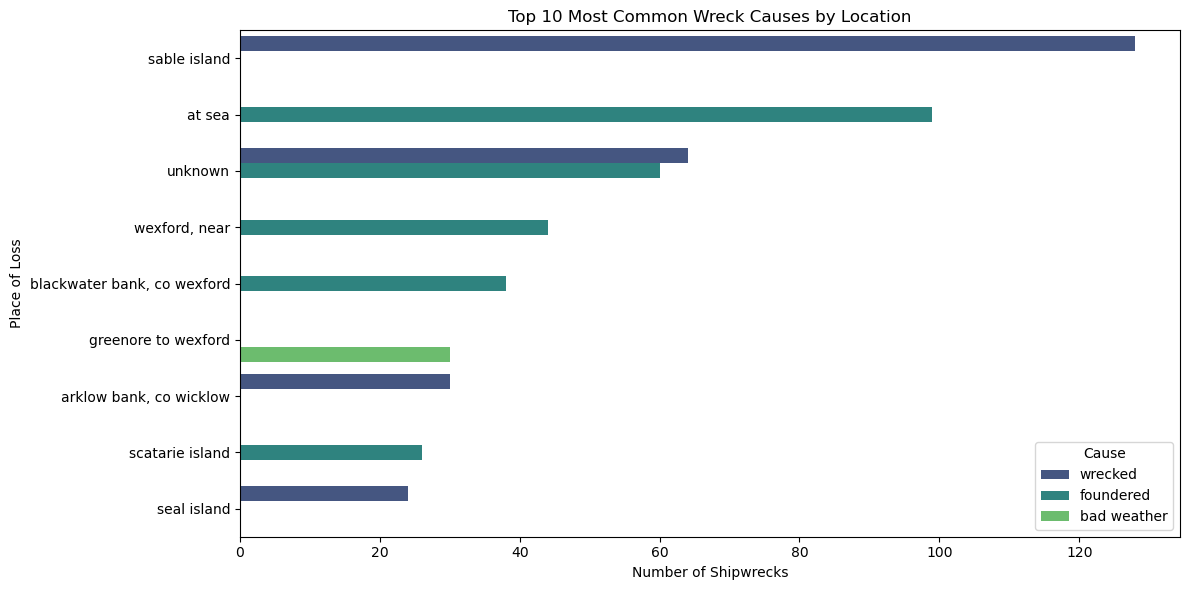

In [22]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_combinations, x='count', y='place_of_loss', hue='cause', palette='viridis')
plt.title("Top 10 Most Common Wreck Causes by Location")
plt.xlabel("Number of Shipwrecks")
plt.ylabel("Place of Loss")
plt.legend(title='Cause')
plt.tight_layout()
plt.show()



In [23]:
# Normalize place names in the dataset
df['place_of_loss_clean'] = (
    df['place_of_loss']
    .astype(str)
    .str.lower()
    .str.strip()
)



In [24]:
# Calculate probabilities per place
place_cause_prob = (
    df.groupby(['place_of_loss_clean', 'cause'])
      .size()
      .groupby(level=0)
      .apply(lambda x: x / x.sum())
)



In [30]:
 def predict_wreck_chance(place_name):
    """Return probability distribution of wreck causes for a given location."""
    place = place_name.lower().strip()

    if place not in place_cause_prob.index.get_level_values(0):
        print(f"No historical data for place: {place_name}")
        return None

    probs = place_cause_prob.loc[place]
    print(f"\nPredicted wreck cause probabilities for '{place_name}':\n")
    for cause, p in probs.items():
        print(f"{cause:20s} : {p*100:.2f}%")

    return probs



In [ ]:
# Interactive user input
while True:
    place = input("Enter a location (or 'quit' to exit): ")

    if place.lower() == "quit":
        break

    predict_wreck_chance(place)


Enter a location (or 'quit' to exit):  Red sea


No historical data for place: Red sea
